In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_colwidth', 100)

In [2]:
BASE = Path('../data/raw')

df_resume = pd.read_csv(BASE / 'resume-dataset/Resume/Resume.csv')
df_jobs = pd.read_csv(BASE / 'linkedin-job-postings/postings.csv')
df_skills = pd.read_csv(BASE / 'linkedin-job-postings/jobs/job_skills.csv')

In [3]:
print("=== RESUME ===")
print(df_resume.shape)
print(df_resume.dtypes)
df_resume.head(3)

=== RESUME ===
(2484, 4)
ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR Summary Dedicated Cu...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS Summary Versatile media professional with ba...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=...",HR
2,33176873,"HR DIRECTOR Summary Over 20 years experience in recruiting, 15 plus years ...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=...",HR


In [4]:
print("=== JOBS ===")
print(df_jobs.shape)
print(df_jobs.dtypes)
df_jobs.head(3)

=== JOBS ===
(123849, 31)
job_id                          int64
company_name                      str
title                             str
description                       str
max_salary                    float64
pay_period                        str
location                          str
company_id                    float64
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type               str
applies                       float64
original_listed_time          float64
remote_allowed                float64
job_posting_url                   str
application_url                   str
application_type                  str
expiry                        float64
closed_time                   float64
formatted_experience_level        str
skills_desc                       str
listed_time                   float64
posting_domain                    str
sponsored                       int64
work_type               

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing C...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with schoo...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer h...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0


In [5]:
df_resume.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [6]:
df_jobs.isnull().sum()

job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency                       87776
c

In [7]:
df_resume['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [8]:
df_jobs['formatted_experience_level'].value_counts()

formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

# NLP Job Screener — EDA

## Datasets

### Resume Dataset
- Source: Kaggle (snehaanbhawal/resume-dataset)
- Shape: 2484 rows, 4 columns
- Columns used: `Resume_str`, `Category`
- Missing values: none
- Classes: 24, distribution relatively balanced (22–120 samples per class)

### LinkedIn Job Postings
- Source: Kaggle (arshkon/linkedin-job-postings)
- Shape: 123,849 rows, 31 columns
- Columns used: `job_id`, `title`, `description`, `formatted_experience_level`, `location`, `formatted_work_type`
- Key observations on missing values:
  - `description` — 7 missing (negligible)
  - `formatted_experience_level` — 29,409 missing (~24%)
  - `skills_desc` — 121,410 missing (column unusable; skills will be extracted from `description`)
  - `remote_allowed` — 108,603 missing (will not be used)

In [10]:
df_resume['text_len'] = df_resume['Resume_str'].str.split().str.len()
df_resume['text_len'].describe()

count    2484.000000
mean      811.325684
std       371.006906
min         0.000000
25%       651.000000
50%       757.000000
75%       933.000000
max      5190.000000
Name: text_len, dtype: float64

In [11]:
df_jobs['desc_len'] = df_jobs['description'].str.split().str.len()
df_jobs['desc_len'].describe()

count    123842.000000
mean        523.057493
std         301.923614
min           1.000000
25%         298.000000
50%         477.000000
75%         696.000000
max        3400.000000
Name: desc_len, dtype: float64

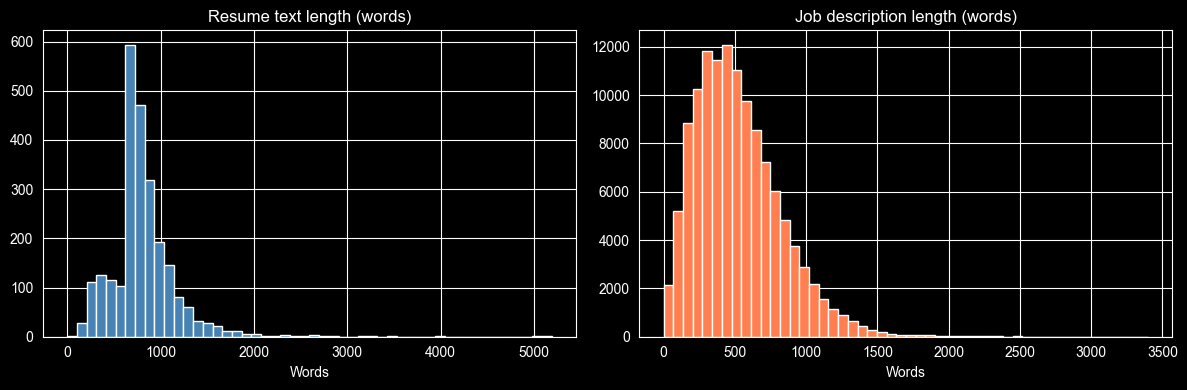

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_resume['text_len'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Resume text length (words)')
axes[0].set_xlabel('Words')

df_jobs['desc_len'].hist(bins=50, ax=axes[1], color='coral')
axes[1].set_title('Job description length (words)')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

In [13]:
df_resume['text_len'].describe()

count    2484.000000
mean      811.325684
std       371.006906
min         0.000000
25%       651.000000
50%       757.000000
75%       933.000000
max      5190.000000
Name: text_len, dtype: float64

In [14]:
df_jobs['desc_len'].describe()

count    123842.000000
mean        523.057493
std         301.923614
min           1.000000
25%         298.000000
50%         477.000000
75%         696.000000
max        3400.000000
Name: desc_len, dtype: float64

In [15]:
(df_resume['text_len'] == 0).sum()

np.int64(1)

In [16]:
(df_resume['text_len'] > 2000).sum()

np.int64(29)

In [17]:
(df_jobs['desc_len'] < 50).sum()

np.int64(1263)

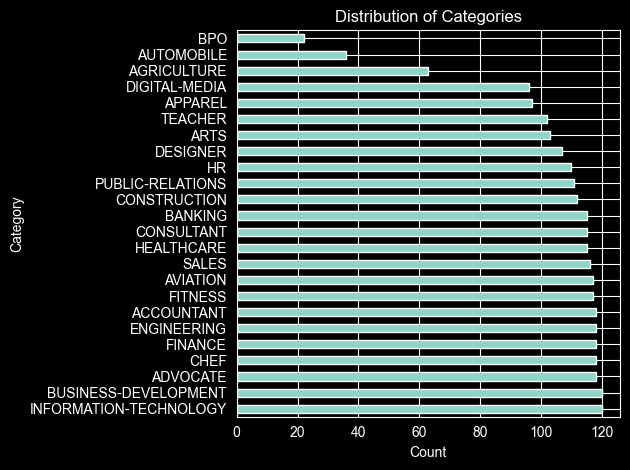

In [20]:
df_resume['Category'].value_counts().plot(kind='barh')
plt.xlabel("Count")
plt.ylabel("Category")
plt.title("Distribution of Categories")
plt.tight_layout()
plt.show()

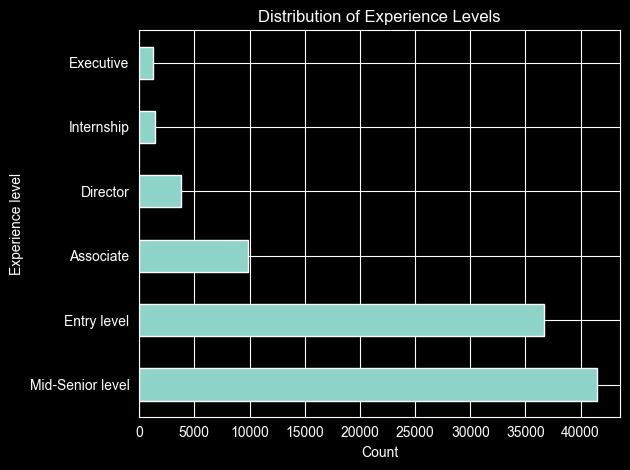

In [21]:
df_jobs['formatted_experience_level'].value_counts().plot(kind='barh')
plt.xlabel("Count")
plt.ylabel("Experience level")
plt.title("Distribution of Experience Levels")
plt.tight_layout()
plt.show()

## Text Length Analysis

**Resume:**
- Mean: 811 words, median: 757, max: 5190
- 1 empty resume (text_len == 0)
- 29 resumes exceed 2000 words (~1.2%)

**Job Descriptions:**
- Mean: 523 words, median: 477, max: 3400
- 1,263 descriptions under 50 words (~1%)

## Data Quality

- Resume dataset: clean, no missing values
- Jobs dataset: `description` has 7 missing values (negligible)
- `skills_desc` unusable (98% missing) — skills will be extracted from `description`
- `formatted_experience_level` has ~24% missing — classifier will train only on labeled subset

## Class Distribution

- Resume: 24 categories, mostly balanced (22–120 samples); BPO and AUTOMOBILE are underrepresented
- Experience levels: heavily imbalanced — Mid-Senior and Entry level dominate; Executive and Internship are rare classes

## Key Decisions for Preprocessing

- Drop `Resume_html`, keep only `Resume_str` and `Category`
- Remove 1 empty resume
- Remove job descriptions shorter than 50 words
- Truncate texts to 512 tokens for SBERT (handle in preprocessing)
- For classifier: use stratified split + `class_weight='balanced'`
- For underrepresented resume categories (BPO, AUTOMOBILE): consider merging or reweighting at modeling stage